## Results from a single calculation

In [ ]:
## Imports
import os
N_cores = 1
os.environ["OMP_NUM_THREADS"] = str(N_cores)        # export OMP_NUM_THREADS=4
os.environ["OPENBLAS_NUM_THREADS"] = str(N_cores)   # export OPENBLAS_NUM_THREADS=4
os.environ["MKL_NUM_THREADS"] = str(N_cores)        # export MKL_NUM_THREADS=6
os.environ["VECLIB_MAXIMUM_THREADS"] = str(N_cores) # export VECLIB_MAXIMUM_THREADS=4
os.environ["NUMEXPR_NUM_THREADS"] = str(N_cores)    # export NUMEXPR_NUM_THREADS=6

import numpy as np
import matplotlib.pyplot as plt

import jclsquant as jcl
import sys
sys.path.append('Code/Neq_TFM')

from ham_creation import create_graphene_ham
from lat_creation import get_positions_graphene
from core import DOS_sparse, frequency_analysis
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
# Benchmarking
from time import time
from datetime import timedelta

# ------------------------------------------------------------------------------
####  Defining a hamiltonian (own)
N_pot = 17
N = 2**N_pot
N1 = N2 = int(np.sqrt(N))//2
S = get_positions_graphene(N1, N2)

Ham = create_graphene_ham(S, N1, N2, out_format='ELL')

dE = (Ham.bounds[1] - Ham.bounds[0])/2

In [ ]:
#### PARAMETERS   
# Energy in pulse                        
E = 1            
# Temperature                       
Temp = 1e-9
# Chemical potential
mu = 0.40
# Amount of periods to be simulated
n_periods = 100
# Amount of half multiples of E where the occupation is obtained
hE_reps = 2
# ??
tau = 0.0 
# Amount of measures per period
meas_per_T = 8
N_measures = meas_per_T*n_periods
# Parameters of the laser
w = E/jcl.hbar_fs 
T = 2*np.pi/w                            
# Time of  (fs)
steps_per_T = 1000
t_vec = np.linspace(0,n_periods*T , steps_per_T*n_periods)      
# Type of light               
modifier_id = 'circle'
# Intensity param     (no units)
gamma = 0.010        

# Intensity of the laser
Phi0 = jcl.hbar_fs*2*np.pi
A0 = gamma*Phi0/(2*3**0.5*jcl.a_cc)

# Amount of random vectors used in calculation
N_random_vector = 5

# Momenta
M = int(np.sqrt(N))
#M = 362
# Broadening in the energies
broad = dE*np.pi/M

t_vec_measures = np.linspace(0, n_periods*T, N_measures)

# Range of searching the maximim frequency (in period^-1 units)
range_search = 1

In [ ]:
# Print of parameters to check results
print('PARAMETERS OF ANALYSIS')
print()
print(f'Type of light is {modifier_id}')
print(f'# of atoms: {N}')
print(f'Energy: {E} eV')
print(f'Intensity param: {gamma}')
print(f'Temperature: {Temp} K')
print(f'Chem potential: {mu} eV')
print(f'# of periods: {n_periods}')
print(f'steps/period: {steps_per_T}')
print(f'# measures/T: {meas_per_T}')

PARAMETERS OF ANALYSIS

Type of light is circle
# of atoms: 131072
Energy: 1 eV
Intensity param: 0.01
Temperature: 1e-09 K
Chem potential: 0.4 eV
# of periods: 100
steps/period: 1000
# measures/T: 8


In [ ]:
# Names of res files used
folder_name = f'{modifier_id}/G={gamma:.3f}_E={float(E)}_Temp={Temp}_mu={mu:.2f}/N={N_pot}_M={M}_R={N_random_vector}_nT={n_periods}_measT={meas_per_T}_stT={steps_per_T}'

# Information in the Suptitle of the graph
fig_title_info = f'$N={{{2**N_pot}}}$, E={E} eV, T={Temp} K, $\\mu$={mu} eV, $\\Gamma$={gamma}, M={M}'

# Information on the box of the graph
extra_text = f'Light: {modifier_id}\n$\\delta E={broad:.3f}$\n# Rand Vecs: {N_random_vector}\nMeasures/T={meas_per_T}\nSteps/T={steps_per_T}'

In [ ]:
# Loading the info in the .npy files available at the moment
if N_random_vector == 1:
    EF_list = np.load(f'Out/{folder_name}/E.npy')
    n_E_list = np.load(f'Out/{folder_name}/n_E.npy')
    dos_list = np.load(f'Out/{folder_name}/dos_E.npy')
else:
    # See the amount calculated in the corresponding folder
    R_calc = len(os.listdir(f'Out/{folder_name}/Ene_R'))
    print(f'{R_calc}/{N_random_vector} calculations finished! Showing results...')
    EF_list = np.load(f'Out/{folder_name}/Ene_R/1.npy')
    n_E_list = np.zeros_like(EF_list)
    dos_list = np.zeros_like(EF_list)
    for i in range(1, R_calc+1):
        n_E_list += np.load(f'Out/{folder_name}/noc_R/{i}.npy')
        dos_list += np.load(f'Out/{folder_name}/dos_R/{i}.npy')
    n_E_list /= R_calc
    dos_list /= R_calc
            
# Remaking the graphs of oscillations in time
hE_list = [hE*E/2 for hE in range(-hE_reps, hE_reps+1)]

5/5 calculations finished! Showing results...


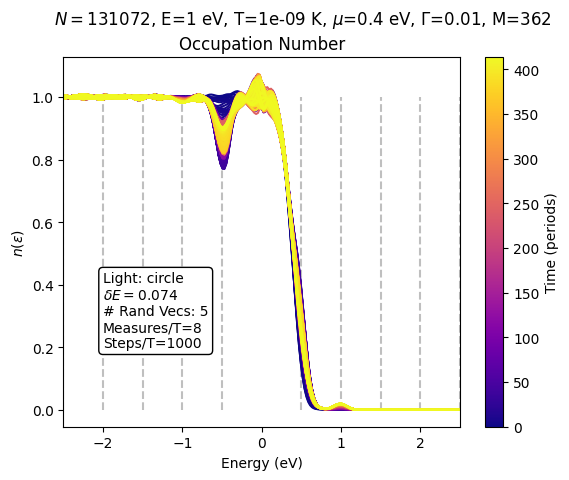

In [ ]:
# Occupation graph

cmap = plt.cm.plasma 
norm = Normalize(vmin=t_vec.min(), vmax=t_vec.max())
min_e, max_e = -2.5, 2.5
hw_lines_step = 0.5
hw_hlines = [i*E for i in [hw_lines_step*i for i in range(1, int(max_e/hw_lines_step+1))]]
hw_hlines += [i*E for i in [-hw_lines_step*i for i in range(1, int(max_e/hw_lines_step+1))]]

# Text box
props = dict(boxstyle='round', facecolor='white', alpha=1.0)

fig, ax = plt.subplots()
for i in range(N_measures):
    ax.plot(EF_list[i,:], n_E_list[i,:], color=cmap(norm(t_vec_measures[i])), label=f't={round(t_vec_measures[i]/T, 3)}T')
#ax.legend()
cbar = fig.colorbar(ScalarMappable(norm=norm, cmap=cmap), ax=ax, orientation='vertical', label='Time (periods)')
ax.set_xlabel('Energy (eV)')
ax.set_ylabel('$n(\\varepsilon)$')
ax.set_xlim(min_e, max_e)
ax.vlines(hw_hlines, 0, 1, color='grey', ls='--', alpha=0.5, zorder=1)
fig.suptitle(fig_title_info)
ax.set_title('Occupation Number')
ax.text(min_e + 0.5, 0.2, extra_text, bbox=props)
fig.savefig(f'Out/{folder_name}/N(E).png', bbox_inches='tight')

In [ ]:
# DOS graph
fig, ax = plt.subplots()
for i in range(N_measures):
    ax.plot(EF_list[i,:], dos_list[i,:], color=cmap(norm(t_vec_measures[i])), label=f't={round(t_vec_measures[i]/T, 3)}T')
#ax.legend()
cbar = fig.colorbar(ScalarMappable(norm=norm, cmap=cmap), ax=ax, orientation='vertical', label='Time (periods)')
ax.set_xlabel('Energy (eV)')
ax.set_ylabel('$n(\\varepsilon)$')
#ax.vlines(hw_hlines, 0, np.max(dos_list), color='grey', ls='--', alpha=0.5, zorder=1)
ax.vlines([0], 0, np.max(dos_list), color='grey', ls='--', alpha=0.8, zorder=1)
fig.suptitle(fig_title_info)
ax.set_title('Density of States')
fig.savefig(f'Out/{folder_name}/dos(E).png', bbox_inches='tight')
plt.show()